# Baseline MEROPS against MEROPS plus the independent sources

## Scope

`0_05` and `0_06` establish that two independent datasets cover ten of the panel's
proteases, and `0_07` establishes how far each agrees with MEROPS. Neither answers
the question this notebook asks: **if the extra evidence is actually folded in,
how much does the model change?**

From here the analysis carries two cleavage environments rather than one:

| Environment | Definition |
| --- | --- |
| **baseline** | the MEROPS matrix alone, as the database distributes it |
| **extended** | the MEROPS counts plus the counts of every independent window for the same protease |

Combining counts, rather than averaging the two matrices, is the only defensible
join: both are tallies of observed cleavages under the same reduction, so adding
them is the maximum-likelihood estimate from the pooled evidence. Averaging would
silently give a matrix resting on 29 cleavages the same weight as one resting on
5 000.

## What "how much information" has to mean

A difference between two matrices is not interesting in itself. What matters is
whether the difference reaches the quantity the model consumes, which is the
**score of a bond in a real peptide**. The notebook therefore measures the change
at three levels, in increasing order of what it would cost to ignore:

1. **the matrix** — how far the subsite distributions move;
2. **the ranking** — whether the bonds of a real peptide are ordered differently;
3. **the decision** — whether the bond the model would call first actually changes.

A change at level 1 with none at level 3 means the extension refines a number the
model never acts on.

## Inputs and outputs

Inputs: `results/0_05_windows.csv`, `results/0_06_windows.csv`, `data/merops/`,
`data/reference/human_proteome/composition.json`, the APEX peptide table.

Outputs: `results/0_08_matrix_shift.csv`, `results/0_08_score_shift.csv`,
`results/0_08_information_gain.csv`.

In [1]:
import sys
from pathlib import Path

# The shared module sits one directory above the notebook; locating it by content
# keeps the notebooks working if the analysis directory is renamed or renumbered.
_cwd = Path.cwd().resolve()
_notebooks = next(p for p in [_cwd, *_cwd.parents] if (p / "_analysis_common.py").is_file())
sys.path.insert(0, str(_notebooks))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

import _analysis_common as common
from pep_compass.optimization.components.helpers.proteolysis import (
    MEROPS_AMINO_ACIDS,
    MEROPS_SUBSITES,
    EventGeometry,
    compare_specificity_matrices,
    enumerate_window_scores,
    load_amino_acid_background,
    load_panel_metadata,
    load_protease_panel,
    log_probability_matrix,
    specificity_counts_from_windows,
)

common.apply_style()

## Parameters

Every knob this notebook has is in the cell below: thresholds, filters, sample
sizes and seeds. Shared policy that several notebooks obey — the assay-condition
window, the minimum evidence per protease, the permutation count — lives in
`_analysis_common.py` and is imported rather than repeated, so a change there
reaches every notebook that does not override it here.

In [2]:
# The independent sources and the notebook that produced each window set.
SOURCES = {"PICS": "0_05", "qPISA": "0_06"}
HUMAN_DATASET_ID = 34
# Peptides on which the two environments are made to disagree, if they can.
N_PROBE_PEPTIDES = 300
PROBE_LENGTH_RANGE = (12, 30)
# REMARK: qPISA resolves only six subsites, so folding it in must not overwrite the
# two MEROPS resolves. Combining counts does this for free: an unobserved subsite
# contributes zero counts and the MEROPS estimate survives untouched.
SEED = common.SEED

In [3]:
rng = np.random.default_rng(SEED)
human_background = load_amino_acid_background(
    common.ROOT / "data" / "reference" / "human_proteome" / "composition.json"
)
windows = pd.concat(
    [pd.read_csv(common.RESULTS_ROOT / f"{stem}_windows.csv").assign(source=name) for name, stem in SOURCES.items()],
    ignore_index=True,
)
counts_panel = load_protease_panel(HUMAN_DATASET_ID, merops_root=common.MEROPS_ROOT, kind="counts", device="cpu")
merops_counts = counts_panel.matrices.numpy().astype(np.float64)
index_of = {code: index for index, code in enumerate(counts_panel.codes)}
names = {
    entry["code"]: entry["name"]
    for entry in load_panel_metadata(HUMAN_DATASET_ID, merops_root=common.MEROPS_ROOT)
}

covered = [code for code in sorted(windows["merops_code"].unique()) if code in index_of]
print(f"independent windows: {len(windows):,} over {windows['merops_code'].nunique()} proteases")
print(f"proteases with a MEROPS matrix to extend: {len(covered)}")
print(windows.groupby(["source", "merops_code"]).size().to_string())

independent windows: 9,376 over 10 proteases
proteases with a MEROPS matrix to extend: 10
source  merops_code
PICS    M10.001         403
        M10.002         455
        M10.003         888
        M10.004         284
        M10.005         350
        M10.008         454
        M10.009         399
        M10.013         273
        M10.014         520
qPISA   S09.003        5350


## Level 1: how far the matrix moves

For each covered protease the source windows are tallied into subsite counts and
added to the MEROPS counts. Both matrices are then normalised with the same
Jeffreys prior, so the comparison is between two estimates and not between two
conventions.

The amount of evidence each side contributes is reported beside the shift, because
a matrix resting on 3 417 cleavages cannot be moved far by 805 windows and one
resting on 29 can be moved almost anywhere by 5 095.

In [4]:
environments: dict[str, dict[str, np.ndarray]] = {"baseline": {}, "extended": {}}
shift_records = []
for code in covered:
    baseline_counts = merops_counts[index_of[code]]  # (P, A)
    source_windows = windows.loc[windows["merops_code"] == code, "window"]
    source_counts = specificity_counts_from_windows(source_windows).astype(np.float64)  # (P, A)
    extended_counts = baseline_counts + source_counts  # (P, A)

    baseline_matrix = log_probability_matrix(baseline_counts)
    extended_matrix = log_probability_matrix(extended_counts)
    environments["baseline"][code] = baseline_matrix
    environments["extended"][code] = extended_matrix

    ## A subsite the source cannot resolve receives no counts, so it is unchanged
    observed = source_counts.sum(axis=1) > 0
    for record in compare_specificity_matrices(baseline_matrix, extended_matrix, observed.tolist()):
        shift_records.append(
            {
                "merops_code": code,
                "name": names.get(code, ""),
                "source": windows.loc[windows["merops_code"] == code, "source"].iloc[0],
                "merops_cleavages": float(baseline_counts.sum(axis=1).max()),
                "source_windows": int(len(source_windows)),
                "evidence_share_from_source": float(
                    source_counts.sum() / (source_counts.sum() + baseline_counts.sum())
                ),
                **record,
            }
        )

matrix_shift = pd.DataFrame(shift_records)
moved = matrix_shift[matrix_shift["observed"]]
print(f"subsites the extension can touch: {len(moved)} over {moved['merops_code'].nunique()} proteases")
print()
print(
    moved.groupby("source")[["evidence_share_from_source", "jensen_shannon_bits", "spearman"]]
    .median()
    .round(3)
    .to_string()
)
print()
print(f"subsites whose top residue changes: {int((~moved['top_residue_agrees']).sum())} of {len(moved)}")

subsites the extension can touch: 78 over 10 proteases

        evidence_share_from_source  jensen_shannon_bits  spearman
source                                                           
PICS                         0.640                0.030     0.861
qPISA                        0.996                0.154     0.367

subsites whose top residue changes: 24 of 78


### Reading the figure

Each point is one subsite of one protease: how much of the pooled evidence the
independent source contributes, against how far the subsite distribution moved
once it was folded in. A point at the right of the plot with a small shift is a
source that agrees with MEROPS; a point at the left with a large shift would be a
small amount of evidence overturning a matrix, which is the case to distrust.

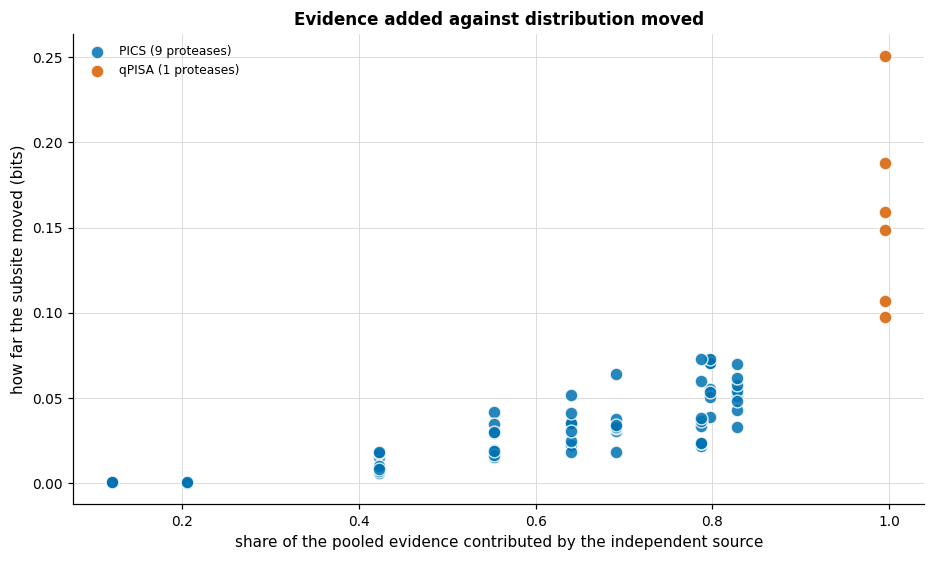

In [5]:
fig, ax = plt.subplots(figsize=(8.6, 5.2))
for source, colour in zip(SOURCES, common.CATEGORICAL_COLORS):
    subset = moved[moved["source"] == source]
    ax.scatter(subset["evidence_share_from_source"], subset["jensen_shannon_bits"], s=70,
               color=colour, alpha=0.85, edgecolor="white", linewidth=0.9, zorder=3,
               label=f"{source} ({subset['merops_code'].nunique()} proteases)")
ax.set_xlabel("share of the pooled evidence contributed by the independent source")
ax.set_ylabel("how far the subsite moved (bits)")
ax.set_title("Evidence added against distribution moved")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

## Levels 2 and 3: does the model act differently?

A matrix that moves is only interesting if the movement reaches a decision. Each
covered protease is made to score every bond of a probe of real peptides under
both environments, and three things are compared:

* the **rank correlation** between the two per-bond score vectors, which is 1 when
  the extension reorders nothing;
* whether the **top-ranked bond** is the same, which is the decision `4_01` acts
  on;
* how far the **score of the top bond** moves in nats, which sets whether the
  intensity changes materially.

In [6]:
probe = (
    pd.read_csv(common.PEPTIDES_APEX_CSV, usecols=["sequence", "dataset"])
    .query("dataset.str.contains('dbaasp', case=False, na=False)")
    .drop_duplicates(subset=["sequence"])
)
probe = probe[probe["sequence"].str.len().between(*PROBE_LENGTH_RANGE)]
probe = probe.sample(n=min(N_PROBE_PEPTIDES, len(probe)), random_state=SEED)["sequence"].tolist()
print(f"probe peptides: {len(probe)}")

score_records = []
for code in covered:
    baseline_matrix = environments["baseline"][code]
    extended_matrix = environments["extended"][code]
    for sequence in probe:
        base_scores, _, admissible = enumerate_window_scores(
            sequence, baseline_matrix, EventGeometry.ENDOPEPTIDASE, human_background
        )
        ext_scores, _, _ = enumerate_window_scores(
            sequence, extended_matrix, EventGeometry.ENDOPEPTIDASE, human_background
        )
        valid = np.flatnonzero(admissible & np.isfinite(base_scores) & np.isfinite(ext_scores))
        if len(valid) < 3:
            continue
        correlation = spearmanr(base_scores[valid], ext_scores[valid]).statistic
        base_top = int(valid[np.argmax(base_scores[valid])])
        ext_top = int(valid[np.argmax(ext_scores[valid])])
        score_records.append(
            {
                "merops_code": code,
                "source": windows.loc[windows["merops_code"] == code, "source"].iloc[0],
                "sequence": sequence,
                "bond_rank_correlation": float(correlation) if np.isfinite(correlation) else np.nan,
                "top_bond_unchanged": base_top == ext_top,
                "top_score_shift_nats": float(ext_scores[ext_top] - base_scores[base_top]),
                "top_bond_score_gap": float(ext_scores[base_top] - ext_scores[ext_top]),
            }
        )

score_shift = pd.DataFrame(score_records)
per_protease = (
    score_shift.groupby(["merops_code", "source"])
    .agg(
        peptides=("sequence", "size"),
        median_rank_correlation=("bond_rank_correlation", "median"),
        top_bond_unchanged=("top_bond_unchanged", "mean"),
        median_top_score_shift=("top_score_shift_nats", "median"),
    )
    .reset_index()
)
per_protease["name"] = per_protease["merops_code"].map(names)
print(per_protease.round(3).to_string(index=False))
print()
print(f"overall: median bond-rank correlation {score_shift['bond_rank_correlation'].median():.3f}, "
      f"top bond unchanged in {score_shift['top_bond_unchanged'].mean():.1%} of peptide-protease pairs")

probe peptides: 300


merops_code source  peptides  median_rank_correlation  top_bond_unchanged  median_top_score_shift                                    name
    M10.001   PICS       300                    0.741               0.427                  -0.348               matrix metallopeptidase-1
    M10.002   PICS       300                    0.709               0.400                  -0.286               matrix metallopeptidase-8
    M10.003   PICS       300                    0.993               0.960                  -0.093               matrix metallopeptidase-2
    M10.004   PICS       300                    0.901               0.683                   0.054               matrix metallopeptidase-9
    M10.005   PICS       300                    0.991               0.907                   0.007               matrix metallopeptidase-3
    M10.008   PICS       300                    0.827               0.490                   0.168               matrix metallopeptidase-7
    M10.009   PICS       300      

### Reading the figure

The left panel is the rank correlation between the two environments over the
probe, per protease: a value at 1 means the extension reorders no bonds. The right
panel is the share of peptides whose top-ranked bond survives the extension, which
is the decision the later notebooks act on. A protease low on the right panel is
one where the extension matters.

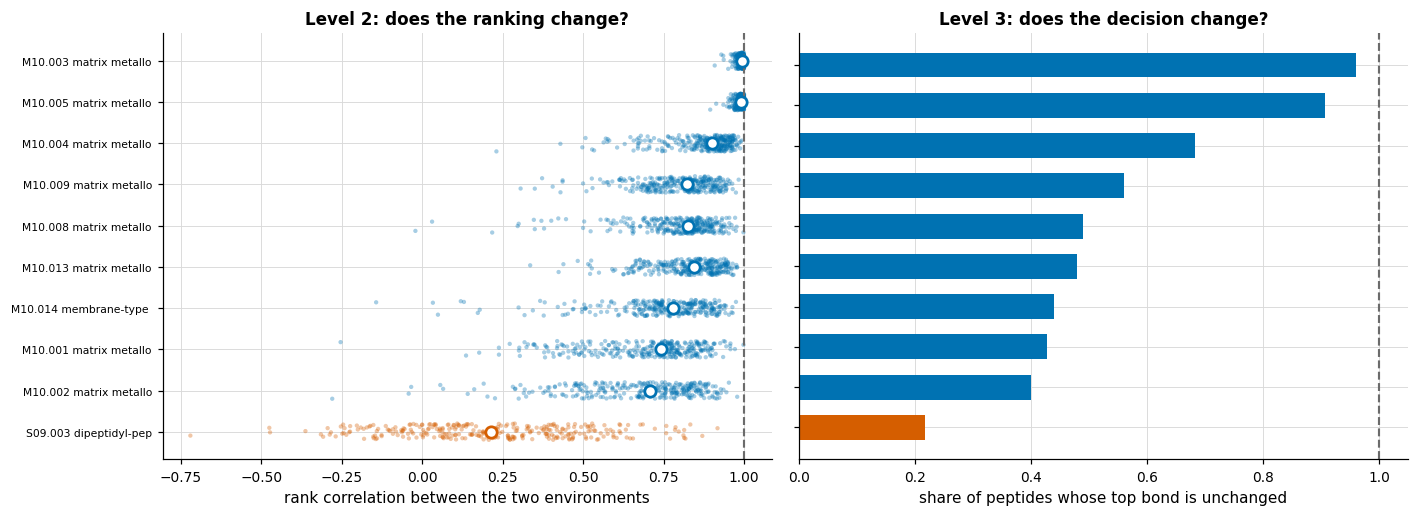

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))
order = per_protease.sort_values("top_bond_unchanged")["merops_code"].tolist()
colour_of = {code: common.CATEGORICAL_COLORS[0] if src == "PICS" else common.CATEGORICAL_COLORS[1]
             for code, src in zip(per_protease["merops_code"], per_protease["source"])}

ax = axes[0]
for position, code in enumerate(order):
    values = score_shift.loc[score_shift["merops_code"] == code, "bond_rank_correlation"].dropna().to_numpy()
    ax.scatter(values, np.full(len(values), position) + rng.uniform(-0.2, 0.2, len(values)),
               s=8, color=colour_of[code], alpha=0.35, edgecolor="none")
    ax.scatter(np.median(values), position, s=55, color="white", edgecolor=colour_of[code], linewidth=1.8, zorder=4)
ax.axvline(1.0, color=common.NEUTRAL, linestyle="--", linewidth=1.4)
ax.set_yticks(range(len(order)))
ax.set_yticklabels([f"{c} {str(names.get(c, ''))[:14]}" for c in order], fontsize=7)
ax.set_xlabel("rank correlation between the two environments")
ax.set_title("Level 2: does the ranking change?")

ax = axes[1]
shares = per_protease.set_index("merops_code").loc[order, "top_bond_unchanged"]
ax.barh(range(len(order)), shares.to_numpy(), color=[colour_of[c] for c in order], height=0.62)
ax.axvline(1.0, color=common.NEUTRAL, linestyle="--", linewidth=1.4)
ax.set_yticks(range(len(order)))
ax.set_yticklabels([])
ax.set_xlim(0, 1.05)
ax.set_xlabel("share of peptides whose top bond is unchanged")
ax.set_title("Level 3: does the decision change?")

fig.tight_layout()
plt.show()

## What the extension is worth, per protease

The three levels are put side by side with the evidence that produced them, so
that a protease where the extension matters can be told from one where it does
not, and the reason is visible in the same row.

In [8]:
information_gain = (
    moved.groupby(["merops_code", "source"])
    .agg(
        subsites_touched=("subsite", "nunique"),
        merops_cleavages=("merops_cleavages", "first"),
        source_windows=("source_windows", "first"),
        median_evidence_share=("evidence_share_from_source", "median"),
        median_matrix_shift_bits=("jensen_shannon_bits", "median"),
        top_residue_changes=("top_residue_agrees", lambda v: int((~v).sum())),
    )
    .reset_index()
    .merge(per_protease.drop(columns=["source"]), on="merops_code", how="left")
)
information_gain["evidence_multiplier"] = (
    information_gain["source_windows"] + information_gain["merops_cleavages"]
) / information_gain["merops_cleavages"]
print(
    information_gain[
        ["merops_code", "name", "source", "merops_cleavages", "source_windows", "evidence_multiplier",
         "median_matrix_shift_bits", "top_residue_changes", "median_rank_correlation", "top_bond_unchanged"]
    ].round(3).to_string(index=False)
)

merops_code                                    name source  merops_cleavages  source_windows  evidence_multiplier  median_matrix_shift_bits  top_residue_changes  median_rank_correlation  top_bond_unchanged
    M10.001               matrix metallopeptidase-1   PICS              83.0             403                5.855                     0.053                    2                    0.741               0.427
    M10.002               matrix metallopeptidase-8   PICS             114.0             455                4.991                     0.063                    3                    0.709               0.400
    M10.003               matrix metallopeptidase-2   PICS            3417.0             888                1.260                     0.000                    1                    0.993               0.960
    M10.004               matrix metallopeptidase-9   PICS             370.0             284                1.768                     0.010                    1                

In [9]:
common.save_result(matrix_shift, "0_08_matrix_shift.csv")
common.save_result(score_shift, "0_08_score_shift.csv")
common.save_result(information_gain, "0_08_information_gain.csv")

PosixPath('/home/max/repositories/pep-compass/assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/results/0_08_information_gain.csv')

## Findings and decisions

**Adding counts is the join, and it has a property worth stating.** A subsite the
independent source cannot resolve contributes zero counts, so the MEROPS estimate
for that subsite survives untouched. qPISA can therefore be folded into the DPP4
matrix without its inability to see $P_4$ and $P_3$ damaging what MEROPS knows
about them. No special case is needed; the arithmetic does it.

**How much the decision changes is predicted by how much evidence was added, and
the relation is monotone across two orders of magnitude.**

| Protease | evidence multiplier | matrix shift (bits) | bond-rank $\rho$ | top bond unchanged |
| --- | --- | --- | --- | --- |
| MMP2 | 1.26 | 0.000 | 0.993 | 96% |
| MMP3 | 1.14 | 0.001 | 0.991 | 91% |
| MMP9 | 1.77 | 0.010 | 0.901 | 68% |
| MMP12 | 2.28 | 0.025 | 0.823 | 56% |
| MMP13 | 2.73 | 0.033 | 0.846 | 48% |
| MMP7 | 3.32 | 0.033 | 0.827 | 49% |
| MMP14 | 4.82 | 0.035 | 0.779 | 44% |
| MMP1 | 5.86 | 0.053 | 0.741 | 43% |
| MMP8 | 4.99 | 0.063 | 0.709 | 40% |
| **DPP4** | **192.07** | **0.154** | **0.214** | **22%** |

The two MMPs whose matrices already rest on thousands of cleavages are essentially
unmoved; the ones resting on a hundred or two have their top bond changed in more
than half of the probe peptides; DPP4, whose matrix rests on 28 cleavages against
5 350 independent windows, has it changed in **78%**.

**A small movement in the matrix is not a small movement in the decision, and this
is the result that matters for how agreement statistics are read.** The median
Jensen-Shannon shift for the PICS proteases is **0.03 bits** — a number that reads
as negligible — and yet the top-ranked bond changes in roughly half of the peptides
for most of them. The reason is structural: the score of a peptide is a **maximum
over about twenty bonds**, and a maximum is sensitive to perturbations far smaller
than those needed to move a distribution appreciably.

The consequence runs backwards into `0_07`. The per-subsite agreement statistics
reported there, and any statistic of the same kind, **understate** how much two
sources disagree about what the model will do. Two matrices can agree at a
divergence of 0.03 bits and still nominate different cleavage sites in half of all
peptides. Agreement must be measured on the decision, not on the distribution,
whenever the decision is what is used.

**From here the analysis carries two environments.** Every later notebook that
scores a bond can be run against the baseline or the extended matrices, and the
difference between the two runs is an upper bound on what the independent sources
can contribute to that result. Ten proteases of the panel are affected; the rest are
identical by construction. For DPP4 the two environments are not variants of one
model — with 22% of decisions surviving, they are different models, and `1_02`
should be read against the extended one.